# 💳 Detección de Fraude en Tarjetas de Crédito

**Objetivo del Proyecto:** Desarrollar un sistema de Machine Learning capaz de identificar transacciones fraudulentas en un volumen masivo de datos. 

**Enfoque Técnico:**
- Optimización de memoria y procesamiento eficiente con Pandas y NumPy.
- Ingeniería de características espaciales y temporales avanzadas.
- Tratamiento de clases altamente desbalanceadas.
- Modelado predictivo enfocado en la métrica PR-AUC.

---

## 1. Configuración Inicial e Importación de Librerías

In [24]:
import pandas as pd
import numpy as np

# Configuración del entorno de visualización del notebook
import warnings
warnings.filterwarnings("ignore") # Oculta avisos molestos de versiones

# Ajustes de Pandas para que no nos oculte columnas al visualizar el DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x) # Evita notación científica


## 2. Ingesta de Datos y Optimización de Memoria (Downcasting)

Al trabajar con más de un millón de transacciones, la eficiencia computacional es una prioridad. Por defecto, Pandas asigna 64 bits a todas las variables numéricas, lo cual genera un consumo de memoria RAM innecesario. 

Para evitarlo, aplicaremos una técnica de **downcasting** desde el propio momento de la lectura. Reduciremos los tipos de datos (por ejemplo, asignando 8 bits a la variable binaria objetivo `is_fraud`) y utilizaremos el motor de `pyarrow` (basado en C++) para la ingesta. Esto no solo comprime la huella de memoria, sino que permite que las futuras operaciones matemáticas se resuelvan de forma mucho más rápida al aprovechar mejor la memoria caché del procesador.

In [25]:
# Ruta absoluta al dataset (usamos 'r' para evitar problemas con las barras de Windows)
dataset_path = r"C:\Users\marti\Portfolio-data-science\ML_Credit_Card_Fraud_Detection\data\credit_card_transactions.csv"

# Definición estricta de tipos de datos para el downcasting
dtypes = {
    'cc_num': 'int64',        # Identificador de la tarjeta (requiere 64 bits por su longitud)
    'amt': 'float32',         # Importe de la transacción
    'lat': 'float32',         # Coordenadas espaciales
    'long': 'float32',
    'merch_lat': 'float32',
    'merch_long': 'float32',
    'city_pop': 'int32',      # Población urbana
    'is_fraud': 'int8'        # Variable objetivo binaria (0 o 1)
}

# Carga apalancada en pyarrow con parseo de fechas al vuelo
print("Cargando el dataset en memoria...")
df = pd.read_csv(
    dataset_path, 
    dtype=dtypes,
    engine='pyarrow',
    parse_dates=['trans_date_trans_time', 'dob']
)

# Limpieza del índice residual de la exportación original
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Comprobación de dimensiones y memoria liberada
print(f"Dimensiones del dataset: {df.shape}\n")
df.info(memory_usage='deep')

Cargando el dataset en memoria...
Dimensiones del dataset: (1296675, 23)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[s] 
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float32       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip            

In [26]:
# visualización de las primeras filas del DataFrame para inspección inicial
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0,28705.0000
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0,NaN
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0,83236.0000
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0,NaN
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0,22844.0000


## 3. Feature Engineering: Variables Espaciales, Temporales y Demográficas

Los algoritmos de Machine Learning no interpretan fechas ni coordenadas brutas de forma eficiente. Para maximizar el poder predictivo, debemos extraer la "señal" subyacente mediante la creación de nuevas variables (*features*):

1. **Señal Espacial:** Calcularemos la distancia ortodrómica (Haversine) entre la ubicación del cliente y el comercio. Transacciones presenciales a gran distancia en cortos periodos de tiempo son fuertes predictores de fraude.
2. **Señal Demográfica:** Convertiremos la fecha de nacimiento (`dob`) en la edad del usuario en el momento de la transacción.
3. **Señal Temporal:** Extraeremos la hora del día y el día de la semana. El fraude suele presentar asimetrías horarias (ej. picos de madrugada).

In [27]:
# Función vectorizada para el cálculo de distancia Haversine en C, se usa esta forma de calculo ya que la Tierra se presume que es una esfera perfecta y no un elipsoide, lo que simplifica los cálculos de distancia entre dos puntos geográficos.
# se calcula de manera vectorizada para evitar un bucle for con .apply() que es mucho más lento y costoso computacionalmente.
def haversine_vectorized(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

df['distancia_km'] = haversine_vectorized(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# Edad del cliente en el momento exacto de la compra
df['edad'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Hora (0-23) y Día de la semana (0=Lunes, 6=Domingo)
df['hora_transaccion'] = df['trans_date_trans_time'].dt.hour
df['dia_semana'] = df['trans_date_trans_time'].dt.dayofweek

# Visualizamos una muestra de las nuevas variables predictoras junto a la variable objetivo
columnas_nuevas = ['trans_date_trans_time', 'distancia_km', 'edad', 'hora_transaccion', 'dia_semana', 'amt', 'is_fraud']
display(df[columnas_nuevas].head())

,trans_date_trans_time,distancia_km,edad,hora_transaccion,dia_semana,amt,is_fraud
0,2019-01-01 00:00:18,78.5975,30,0,1,4.9700,0
1,2019-01-01 00:00:44,30.2122,40,0,1,107.2300,0
2,2019-01-01 00:00:51,108.2061,56,0,1,220.1100,0
3,2019-01-01 00:01:16,95.6738,52,0,1,45.0000,0
4,2019-01-01 00:03:06,77.5564,32,0,1,41.9600,0


## 4. Análisis Exploratorio (EDA): Desbalanceo y Patrones Temporales

El objetivo de esta sección es auditar la distribución de la variable objetivo (`is_fraud`) y analizar la separación de varianza en nuestras nuevas *features* temporales. 

Dado que el fraude es un evento anómalo, visualizaremos la **densidad de probabilidad** de las transacciones legítimas frente a las fraudulentas a lo largo del día. Usar densidades en lugar de recuentos absolutos (KDE - *Kernel Density Estimation*) nos permite comparar la "forma" del comportamiento horario ignorando la masiva diferencia en volumen entre ambas clases.

--- Auditoría de Desbalanceo de Clases ---


,Volumen Absoluto,Proporción (%)
Legítimas (0),1289169,99.4211
Fraude (1),7506,0.5789


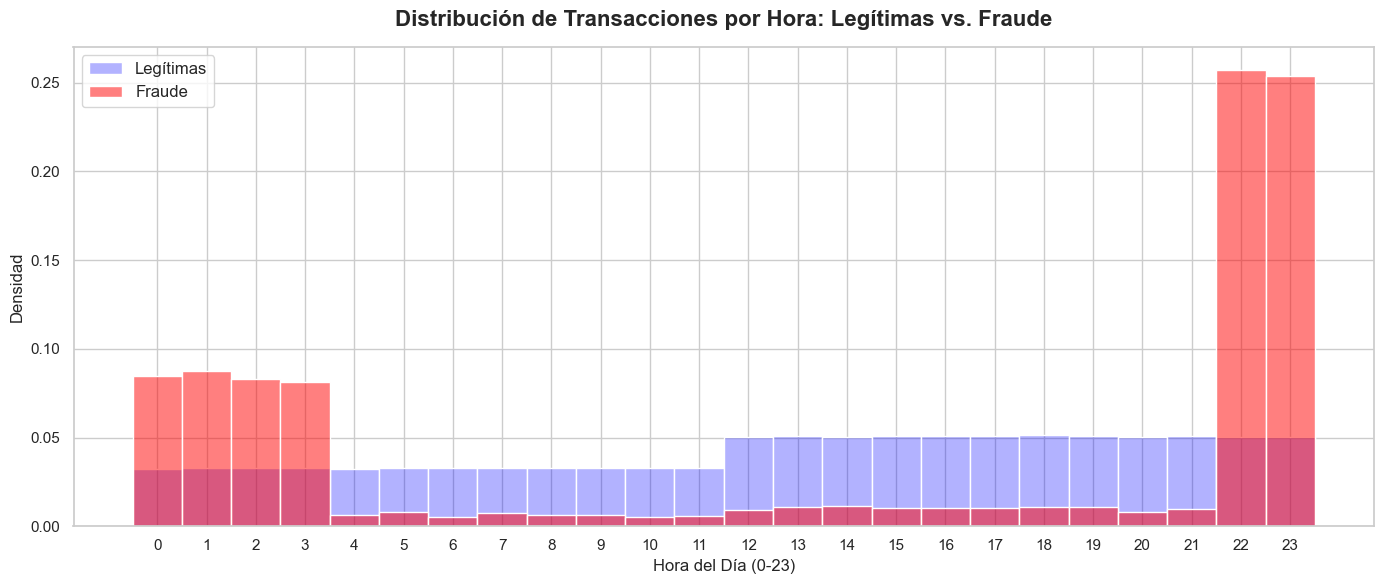

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para los gráficos
sns.set_theme(style="whitegrid", palette="muted")

print("--- Auditoría de Desbalanceo de Clases ---")
# Calculamos frecuencias absolutas y relativas
frecuencias = df['is_fraud'].value_counts()
porcentajes = df['is_fraud'].value_counts(normalize=True) * 100

resumen_fraude = pd.DataFrame({
    'Volumen Absoluto': frecuencias,
    'Proporción (%)': porcentajes
})
resumen_fraude.index = ['Legítimas (0)', 'Fraude (1)']
display(resumen_fraude)


# Gráfico de distribución discreta normalizada
plt.figure(figsize=(14, 6))

# Usamos histplot con discrete=True para que se ciña a las horas enteras (0, 1, 2...)
sns.histplot(data=df[df['is_fraud'] == 0], x='hora_transaccion', color='blue', label='Legítimas', stat='density', discrete=True, alpha=0.3)
sns.histplot(data=df[df['is_fraud'] == 1], x='hora_transaccion', color='red', label='Fraude', stat='density', discrete=True, alpha=0.5)

# Formateo del gráfico
plt.title('Distribución de Transacciones por Hora: Legítimas vs. Fraude', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

Proyección cíclica de las variables temporales (hora del día y día de la semana) usando funciones trigonométricas para capturar la naturaleza circular de estas características. Esto es crucial para modelos que no manejan bien la discontinuidad entre el final y el inicio del ciclo (por ejemplo, entre las 23:00 y las 00:00 horas).

In [29]:
# Transformación trigonométrica para la hora del día (ciclo de 24 horas)
df['hora_sin'] = np.sin(2 * np.pi * df['hora_transaccion'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora_transaccion'] / 24)

# Transformación trigonométrica para el día de la semana (ciclo de 7 días)
df['dia_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7)
df['dia_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7)

# Visualizamos la transformación
display(df[['hora_transaccion', 'hora_sin', 'hora_cos']].head())

,hora_transaccion,hora_sin,hora_cos
0,0,0.0000,1.0000
1,0,0.0000,1.0000
2,0,0.0000,1.0000
3,0,0.0000,1.0000
4,0,0.0000,1.0000


## 4.1. Auditoría de Cardinalidad en Variables Categóricas

Antes de definir la estrategia de codificación matemática para la matriz $X$, es imperativo analizar la cardinalidad (número de valores únicos) de las variables cualitativas. 

- **Baja Cardinalidad:** Variables con pocos estados (ej. género). Son idóneas para *One-Hot Encoding*.
- **Alta Cardinalidad:** Variables con miles de estados (ej. comercios, ciudades). Si aplicamos *One-Hot Encoding*, provocaremos una explosión de dimensionalidad que saturará la memoria y causará la maldición de la dimensionalidad (*Curse of Dimensionality*). Estas variables requieren técnicas avanzadas como *Frequency Encoding* o *Target Encoding*.

In [30]:
print("--- Análisis de Cardinalidad ---")

# Seleccionamos dinámicamente todas las columnas cualitativas (texto)
variables_categoricas = df.select_dtypes(include=['object']).columns

# Calculamos los valores únicos y su proporción sobre el total del dataset
cardinalidad = []
for col in variables_categoricas:
    valores_unicos = df[col].nunique()
    porcentaje_unicos = (valores_unicos / len(df)) * 100
    cardinalidad.append({
        'Variable': col,
        'Valores Únicos': valores_unicos,
        '% del Total de Filas': porcentaje_unicos
    })

# Convertimos a DataFrame para una visualización analítica limpia
df_cardinalidad = pd.DataFrame(cardinalidad).sort_values(by='Valores Únicos', ascending=False)

# Aplicamos un gradiente de color para identificar visualmente el peligro de explosión dimensional
display(df_cardinalidad.style.format({'% del Total de Filas': '{:.4f}%'}).background_gradient(cmap='OrRd', subset=['Valores Únicos']))

--- Análisis de Cardinalidad ---


,Variable,Valores Únicos,% del Total de Filas
9,trans_num,1296675,100.0000%
5,street,983,0.0758%
6,city,894,0.0689%
0,merchant,693,0.0534%
8,job,494,0.0381%
3,last,481,0.0371%
2,first,352,0.0271%
7,state,51,0.0039%
1,category,14,0.0011%
4,gender,2,0.0002%


## 5. Preprocesamiento: Codificación Inteligente y Train-Test Split

Basándonos en la auditoría de cardinalidad, aplicaremos un preprocesamiento diferenciado:

1. **Eliminación de Ruido Absoluto:** Descartamos identificadores únicos que solo generarían memorización (*overfitting*).
2. **Frequency Encoding:** Para las variables de alta cardinalidad, sustituimos el texto por su frecuencia estadística de aparición.
3. **One-Hot Encoding:** Para variables de baja cardinalidad (género, categoría).
4. **Shadow Features (Control):** Inyectamos variables puramente aleatorias. Cualquier característica real que en el modelado tenga menor importancia que estas variables, será considerada ruido y descartada empíricamente.
5. **Muestreo Estratificado:** Partición 80/20 garantizando que la proporción de fraudes se mantenga constante.

In [32]:
from sklearn.model_selection import train_test_split

print("1. Eliminando identificadores únicos (Ruido absoluto)...")
# merch_zipcode ya NO se elimina aquí
columnas_ruido = ['trans_num', 'first', 'last', 'dob', 'unix_time', 'cc_num']
df_ml = df.drop(columns=columnas_ruido)

print("2. Imputación de Valores Nulos (Missing Category Indicator)...")
# Convertimos los nulos en una categoría explícita y forzamos el tipo texto
df_ml['merch_zipcode'] = df_ml['merch_zipcode'].fillna('desconocido').astype(str)

print("3. Aplicando Frequency Encoding a variables de alta cardinalidad...")
# Añadimos merch_zipcode a la lista para transformarlo en frecuencias matemáticas
cols_alta_cardinalidad = ['merchant', 'job', 'city', 'state', 'street', 'merch_zipcode']
for col in cols_alta_cardinalidad:
    frecuencia = df_ml[col].value_counts(normalize=True)
    df_ml[col + '_freq'] = df_ml[col].map(frecuencia).astype('float32')

# Borramos los textos originales
df_ml = df_ml.drop(columns=cols_alta_cardinalidad)

print("4. Codificando variables de baja cardinalidad (One-Hot)...")
df_ml = pd.get_dummies(df_ml, columns=['gender', 'category'], drop_first=True, dtype='int8')

print("5. Inyectando variables aleatorias de control (Shadow Features)...")
np.random.seed(42)
df_ml['random_control_normal'] = np.random.normal(0, 1, df_ml.shape[0]).astype('float32')
df_ml['random_control_uniform'] = np.random.uniform(0, 1, df_ml.shape[0]).astype('float32')

print("6. Separando matriz predictora (X) y vector objetivo (y)...")
X = df_ml.drop(columns=['is_fraud'])
y = df_ml['is_fraud']

print("7. Ejecutando partición estratificada (80% Train / 20% Test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  
)

print("\n--- Resumen de la Matriz X_train ---")
print(f"Dimensiones: {X_train.shape}")
display(X_train.head())

1. Eliminando identificadores únicos (Ruido absoluto)...
2. Imputación de Valores Nulos (Missing Category Indicator)...
3. Aplicando Frequency Encoding a variables de alta cardinalidad...
4. Codificando variables de baja cardinalidad (One-Hot)...
5. Inyectando variables aleatorias de control (Shadow Features)...
6. Separando matriz predictora (X) y vector objetivo (y)...
7. Ejecutando partición estratificada (80% Train / 20% Test)...

--- Resumen de la Matriz X_train ---
Dimensiones: (1037340, 38)


,trans_date_trans_time,amt,zip,lat,long,city_pop,merch_lat,merch_long,distancia_km,edad,hora_transaccion,dia_semana,hora_sin,hora_cos,dia_sin,dia_cos,merchant_freq,job_freq,city_freq,state_freq,street_freq,merch_zipcode_freq,gender_M,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,random_control_normal,random_control_uniform
509059,2019-08-09 03:13:27,51.7100,13647,44.6087,-74.9732,69,44.7859,-74.6593,31.6846,28,3,4,0.7071,0.7071,-0.4339,-0.9010,0.0007,0.0055,0.0020,0.0644,0.0020,0.0000,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-1.8058,0.3364
395295,2019-06-29 19:56:48,13.7800,76665,31.9290,-97.6443,2526,31.4140,-98.1522,74.7613,48,19,5,-0.9659,0.2588,-0.9749,-0.2225,0.0014,0.0024,0.0039,0.0732,0.0020,0.0001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.9246,0.2267
536531,2019-08-18 14:42:20,961.2600,98238,48.3400,-122.3456,85,49.1185,-122.6221,88.9128,34,14,6,-0.5000,-0.8660,-0.7818,0.6235,0.0018,0.0028,0.0036,0.0146,0.0024,0.1511,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-0.5361,0.9328
271001,2019-05-13 21:27:46,43.6800,96135,40.0235,-120.7986,128,39.5281,-121.0600,59.4429,53,21,0,-0.7071,0.7071,0.0000,1.0000,0.0013,0.0008,0.0008,0.0435,0.0008,0.0000,1,0,0,0,0,1,0,0,0,0,0,0,0,0,-1.0826,0.4931
532788,2019-08-17 14:15:41,33.0800,65066,38.3511,-91.4867,6703,39.2138,-92.1882,113.5713,21,14,5,-0.5000,-0.8660,-0.9749,-0.2225,0.0014,0.0067,0.0004,0.0296,0.0004,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0943,0.6700


## 6. Validación de Multicolinealidad (Matriz de Correlación)

Antes de proceder al entrenamiento, auditamos la matriz predictora $X$ en busca de multicolinealidad severa. 
Dado que muchas de nuestras variables no siguen una distribución normal (como las frecuencias o las variables binarias), utilizaremos el **coeficiente de correlación de Spearman** (basado en rangos) en lugar del tradicional de Pearson. 

El objetivo es identificar pares de variables redundantes que puedan desestabilizar la interpretabilidad del modelo o añadir ruido innecesario.

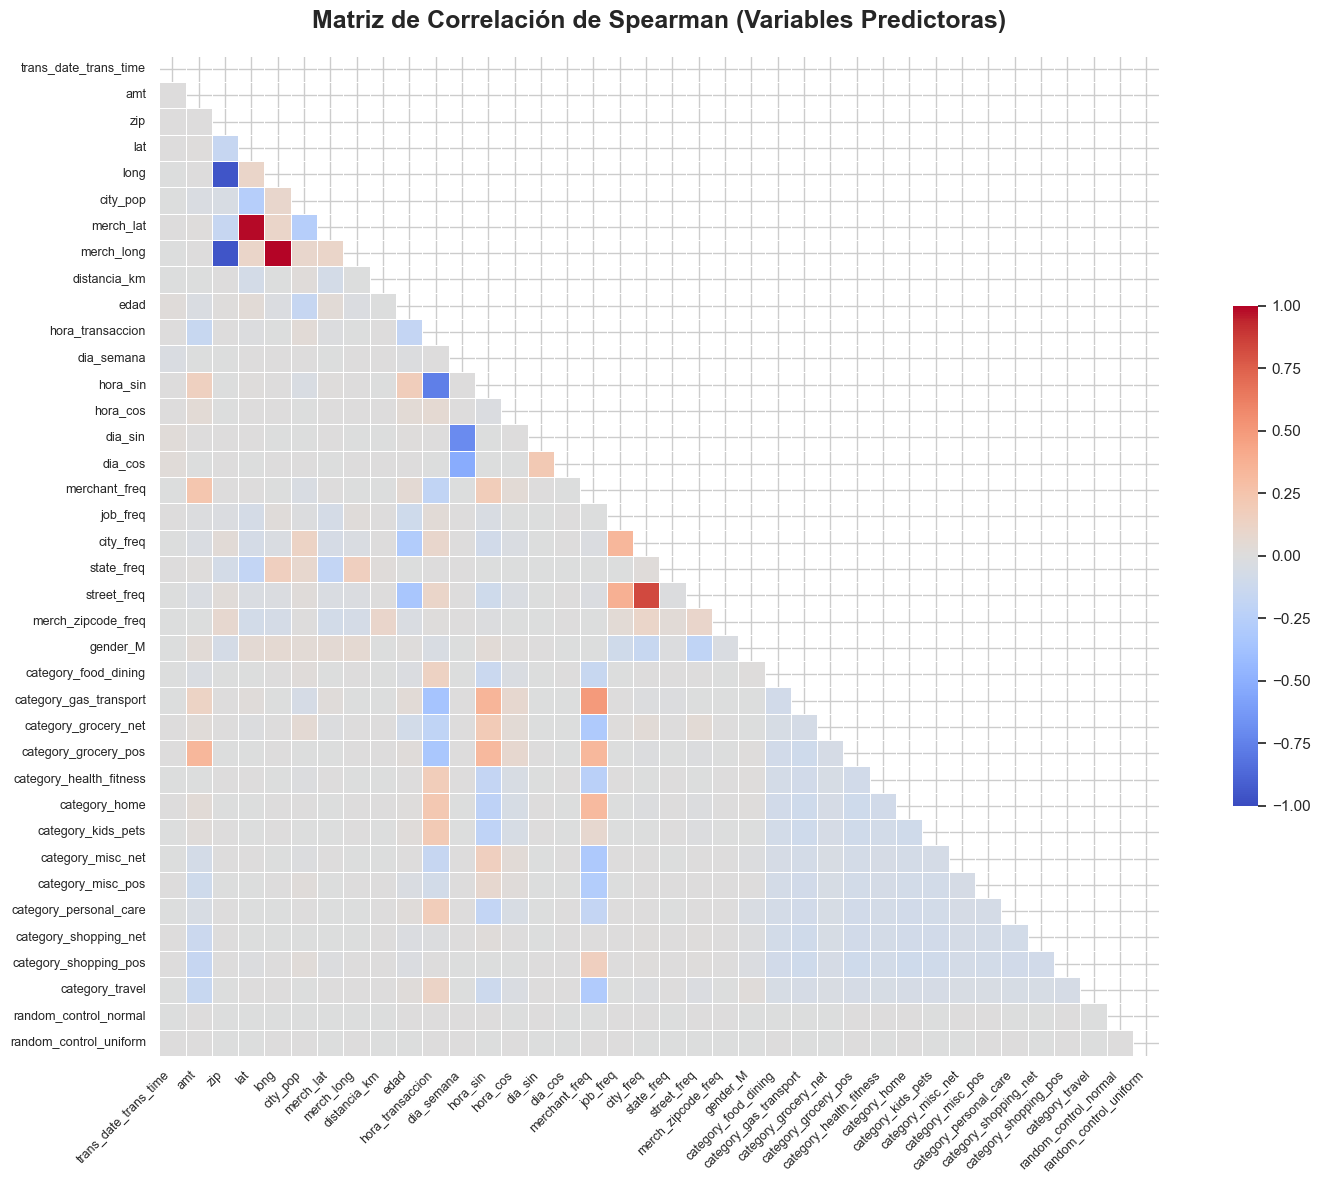


--- Alerta de Alta Correlación (|rho| > 0.85) ---
⚠️ zip y long: -0.9588
⚠️ zip y merch_long: -0.9573
⚠️ lat y merch_lat: 0.9910
⚠️ long y merch_long: 0.9984


In [33]:
# Usamos Spearman por la naturaleza no paramétrica de nuestras features
matriz_corr = X_train.corr(method='spearman')

# Generamos una máscara para ocultar el triángulo superior (evitar información duplicada)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Configuración del lienzo
plt.figure(figsize=(16, 12))

# Renderizado del Heatmap
sns.heatmap(
    matriz_corr, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1, 
    vmin=-1, 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .5}, 
    annot=False # Desactivado porque con tantas columnas los números se solaparían
)

plt.title('Matriz de Correlación de Spearman (Variables Predictoras)', fontsize=18, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

plt.show()

# Extraer los pares con correlación peligrosa (mayor a 0.85 o menor a -0.85)
print("\n--- Alerta de Alta Correlación (|rho| > 0.85) ---")
pares_altos = np.where(np.abs(matriz_corr) > 0.85)
pares_vistos = set()

for i in range(len(pares_altos[0])):
    var1 = matriz_corr.columns[pares_altos[0][i]]
    var2 = matriz_corr.columns[pares_altos[1][i]]
    
    # Evitar la diagonal principal y duplicados
    if var1 != var2 and tuple(sorted([var1, var2])) not in pares_vistos:
        correlacion = matriz_corr.iloc[pares_altos[0][i], pares_altos[1][i]]
        print(f"⚠️ {var1} y {var2}: {correlacion:.4f}")
        pares_vistos.add(tuple(sorted([var1, var2])))

if not pares_vistos:
    print("No se detectó multicolinealidad severa. La matriz X es estable.")

### 6.1. Tratamiento de la Multicolinealidad

El análisis de Spearman revela una colinealidad casi perfecta (>0.95) entre las coordenadas del cliente (`lat`, `long`), las coordenadas del comercio (`merch_lat`, `merch_long`) y el código postal de residencia (`zip`). 

Dado que la información espacial y la desviación geográfica ya han sido encapsuladas de forma óptima en la variable sintética `distancia_km` y en las frecuencias de ubicación, procedemos a eliminar estas variables en bruto para estabilizar el espacio vectorial y evitar la dilución en la importancia de las características (*Feature Importance*).

In [34]:
columnas_colineales = ['lat', 'long', 'merch_lat', 'merch_long', 'zip']

# Eliminamos las variables de ambas particiones para mantener la simetría
X_train = X_train.drop(columns=columnas_colineales)
X_test = X_test.drop(columns=columnas_colineales)

print(f"Nuevas dimensiones de X_train: {X_train.shape}")
print(f"Nuevas dimensiones de X_test : {X_test.shape}")
print("Matriz predictora optimizada y lista para el modelado.")

Nuevas dimensiones de X_train: (1037340, 33)
Nuevas dimensiones de X_test : (259335, 33)
Matriz predictora optimizada y lista para el modelado.


In [36]:
# Eliminamos también la fecha original, ya que su varianza está capturada en las variables cíclicas
X_train = X_train.drop(columns=['trans_date_trans_time'], errors='ignore')
X_test = X_test.drop(columns=['trans_date_trans_time'], errors='ignore')
print(f"Nuevas dimensiones de X_train: {X_train.shape}")
print(f"Nuevas dimensiones de X_test : {X_test.shape}")
print("Matriz predictora optimizada y lista para el modelado.")

print("Listo. Ahora X_train y X_test son 100% numéricos.")

Nuevas dimensiones de X_train: (1037340, 32)
Nuevas dimensiones de X_test : (259335, 32)
Matriz predictora optimizada y lista para el modelado.
Listo. Ahora X_train y X_test son 100% numéricos.


## 7. Modelado Predictivo: XGBoost con Cost-Sensitive Learning

Para la fase de modelado, implementamos un clasificador **eXtreme Gradient Boosting (XGBoost)**. Las ventajas arquitectónicas para este caso de uso son empíricamente superiores:

1. **Aceleración por Hardware:** Uso directo de la GPU (CUDA) para paralelizar la construcción de los árboles de decisión sobre la matriz de entrenamiento de más de 1 millón de registros.
2. **Cost-Sensitive Learning:** Para combatir el desbalanceo severo de clases sin recurrir a sobremuestreo sintético (SMOTE), ajustamos la función de pérdida mediante el parámetro `scale_pos_weight`. Esto asigna una penalización asimétrica a los falsos negativos.
3. **Métrica de Evaluación:** La optimización se rige por el área bajo la curva Precision-Recall (PR-AUC), la métrica más rigurosa para evaluar la separación de varianza en eventos raros.

1. Calculando el peso asimétrico para la función de pérdida (Cost-Sensitive Learning)...
Peso asignado a la clase minoritaria (Fraude): 171.75

2. Instanciando la arquitectura XGBoost sobre la GPU...

3. Entrenando el modelo (Fit)...

4. Generando predicciones sobre el conjunto de test (Out-of-Sample)...

--- INFORME DE RENDIMIENTO (PR-AUC y F1-Score) ---
PR-AUC Score: 0.9219

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257834
           1       0.33      0.97      0.49      1501

    accuracy                           0.99    259335
   macro avg       0.66      0.98      0.74    259335
weighted avg       1.00      0.99      0.99    259335



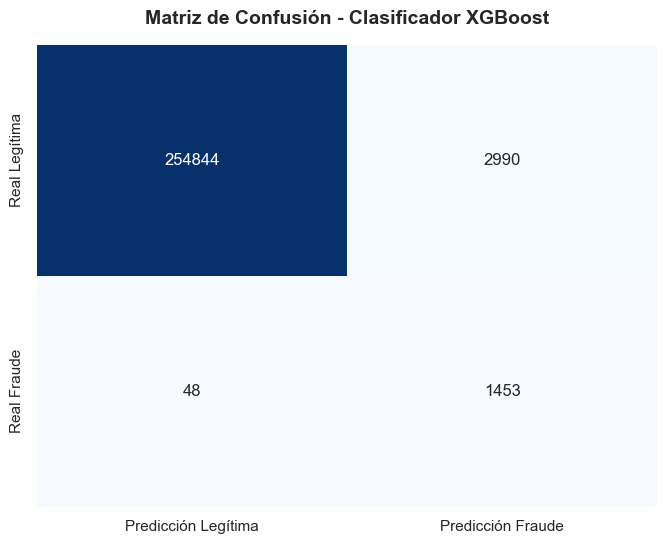

In [37]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, PrecisionRecallDisplay

print("1. Calculando el peso asimétrico para la función de pérdida (Cost-Sensitive Learning)...")
# Ratio: Transacciones Legítimas / Transacciones Fraudulentas
peso_clases = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Peso asignado a la clase minoritaria (Fraude): {peso_clases:.2f}")

print("\n2. Instanciando la arquitectura XGBoost sobre la GPU...")
# Configuración hiper-optimizada para aprovechar la arquitectura CUDA
xgb_model = xgb.XGBClassifier(
    n_estimators=300,            # Número de árboles (boosting rounds)
    learning_rate=0.05,          # Tasa de aprendizaje conservadora para evitar sobreajuste local
    max_depth=6,                 # Profundidad de cada árbol para capturar interacciones complejas
    scale_pos_weight=peso_clases, # Penalización asimétrica para el fraude
    device='cuda',               # REDIRECCIÓN DEL CÓMPUTO A LA TARJETA GRÁFICA
    eval_metric='aucpr',         # Optimización basada en Precision-Recall
    random_state=42,
    n_jobs=-1
)

print("\n3. Entrenando el modelo (Fit)...")
# Aquí es donde la GPU marcará la diferencia de rendimiento
xgb_model.fit(X_train, y_train)

print("\n4. Generando predicciones sobre el conjunto de test (Out-of-Sample)...")
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\n--- INFORME DE RENDIMIENTO (PR-AUC y F1-Score) ---")
# Calculamos el Área bajo la curva Precision-Recall
pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"PR-AUC Score: {pr_auc:.4f}\n")

# Matriz de Confusión y Reporte
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicción Legítima', 'Predicción Fraude'],
            yticklabels=['Real Legítima', 'Real Fraude'])
plt.title('Matriz de Confusión - Clasificador XGBoost', pad=15, fontweight='bold', fontsize=14)
plt.show()

Para ser el primer modelo de prueba los resultados obtenidos son muy buenos, en detección de fraude buscamos maximizar la sensibilidad, es decir, del total de operaciones fraudulentas, cuantas marca el modelo como fraudulentas, en este caso el 97% un dato prometedor, el modelo solo ha dejado pasar 48 operaciones fraudulentas. El trade-off a asumir es un 33% de precisión, es decir de todo lo que el modelo marca como fraude solo el 33% es fraude real por lo que se molestaría a un numero de clientes elevado, en este caso 2990 clientes.

## 8. Explicabilidad del Modelo y Selección de Variables (Feature Importance)

Para garantizar la robustez del algoritmo y evitar el sobreajuste a ruido estadístico, analizamos la importancia de las variables (*Feature Importance*) calculada por el árbol XGBoost (basada en la ganancia de información o *Gain*).

**El umbral empírico de las Shadow Features:**
Durante el preprocesamiento, inyectamos variables puramente aleatorias (`random_control_normal` y `random_control_uniform`). Cualquier variable real cuyo poder predictivo quede por debajo de estas variables de control será considerada ruido matemático y, por tanto, candidata a ser eliminada en futuras iteraciones del modelo.

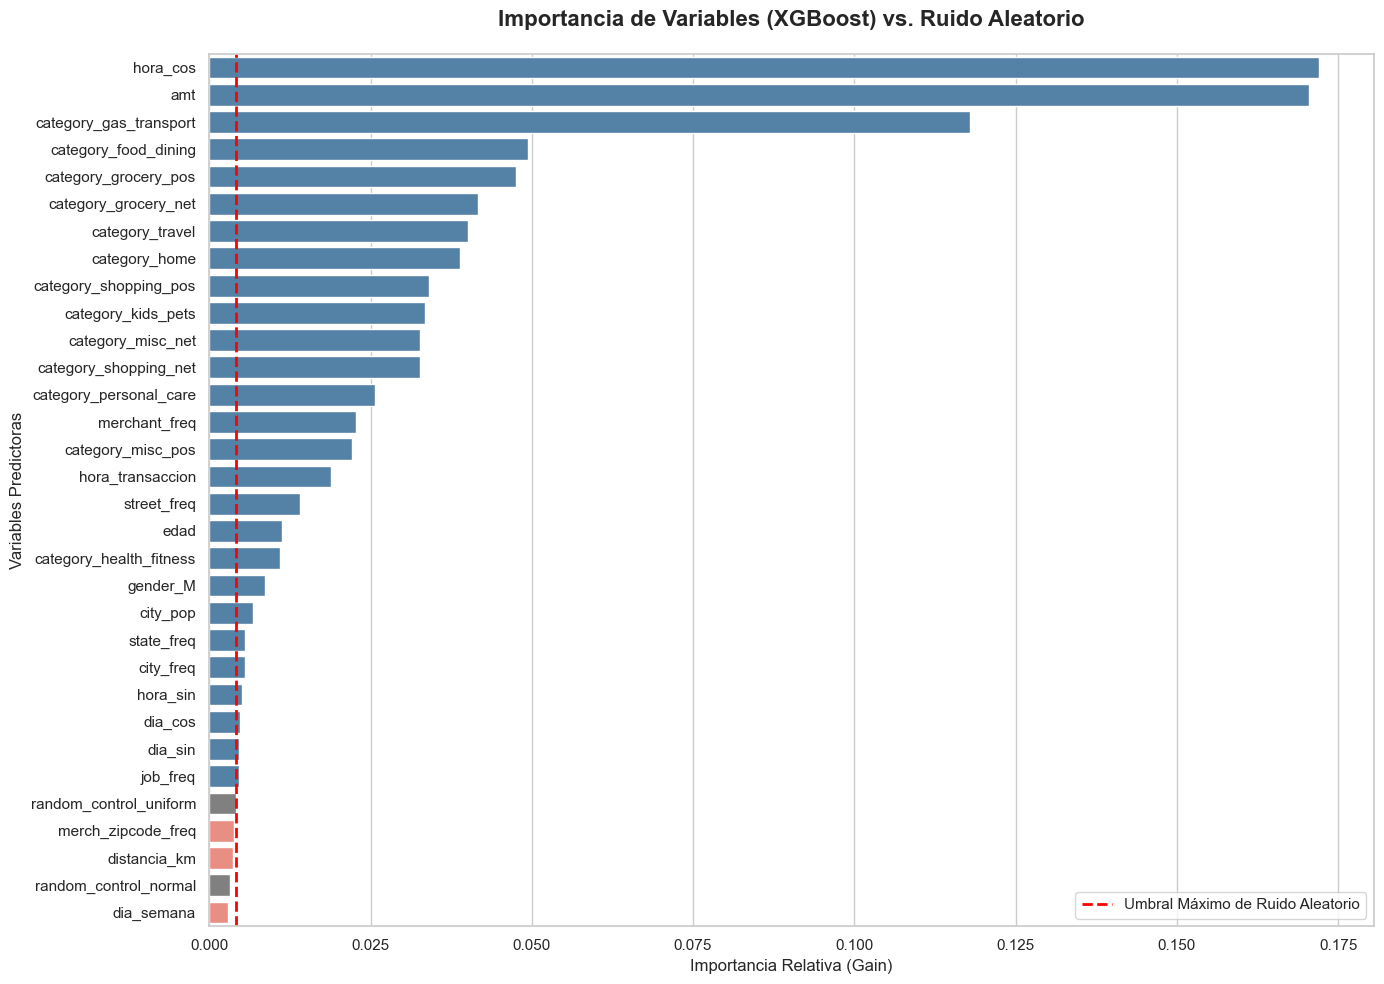

--- Ranking Matemático de Feature Importance (Gain) ---


,Variable,Importancia,Clasificación
7,hora_cos,0.171968,✅ Señal Válida
0,amt,0.170430,✅ Señal Válida
18,category_gas_transport,0.118008,✅ Señal Válida
17,category_food_dining,0.049400,✅ Señal Válida
20,category_grocery_pos,0.047630,✅ Señal Válida
19,category_grocery_net,0.041674,✅ Señal Válida
29,category_travel,0.040106,✅ Señal Válida
22,category_home,0.038938,✅ Señal Válida
28,category_shopping_pos,0.034099,✅ Señal Válida
23,category_kids_pets,0.033438,✅ Señal Válida


In [43]:
# Extracción de la importancia de las variables (Gain)
importancias = xgb_model.feature_importances_
columnas = X_train.columns

# Creación del DataFrame para ordenarlas matemáticamente
df_importancia = pd.DataFrame({
    'Variable': columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Identificamos el umbral de ruido marcado por nuestras Shadow Features
umbral_ruido = df_importancia[df_importancia['Variable'].str.contains('random_control')]['Importancia'].max()

# Configuración visual del gráfico
plt.figure(figsize=(14, 10))

# Asignamos colores: Gris para ruido, Rojo para variables peores que el ruido, Azul para variables útiles
colores = []
for index, row in df_importancia.iterrows():
    if 'random_control' in row['Variable']:
        colores.append('gray')
    elif row['Importancia'] < umbral_ruido:
        colores.append('salmon')
    else:
        colores.append('steelblue')

sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette=colores)

# Añadimos la línea de corte del ruido
plt.axvline(x=umbral_ruido, color='red', linestyle='--', linewidth=2, label='Umbral Máximo de Ruido Aleatorio')

plt.title('Importancia de Variables (XGBoost) vs. Ruido Aleatorio', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importancia Relativa (Gain)', fontsize=12)
plt.ylabel('Variables Predictoras', fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

print("--- Ranking Matemático de Feature Importance (Gain) ---")

# Etiquetamos las variables según si superan a las Shadow Features
df_importancia['Clasificación'] = np.where(
    df_importancia['Importancia'] >= umbral_ruido, 
    '✅ Señal Válida', 
    '❌ Ruido (Descartar)'
)

# Forzamos la etiqueta de control para las variables aleatorias
df_importancia.loc[df_importancia['Variable'].str.contains('random_control'), 'Clasificación'] = '⚠️ Variable de Control'

# Mostramos la tabla con un gradiente de color para el portfolio
display(df_importancia.style.format({'Importancia': '{:.6f}'}).background_gradient(cmap='Blues', subset=['Importancia']))

In [ ]:
# Umbral de corte empírico
umbral_ruido = df_importancia[df_importancia['Variable'].str.contains('random_control')]['Importancia'].max()

# Identificamos variables a eliminar (incluyendo las propias shadow features)
variables_a_eliminar = df_importancia[df_importancia['Importancia'] < umbral_ruido]['Variable'].tolist()
variables_a_eliminar.extend(['random_control_normal', 'random_control_uniform'])

# Limpieza final de la matriz de entrenamiento y prueba
X_train_final = X_train.drop(columns=variables_a_eliminar, errors='ignore')
X_test_final = X_test.drop(columns=variables_a_eliminar, errors='ignore')

print(f"Dimensiones de la matriz original : {X_train.shape[1]} columnas")
print(f"Dimensiones de la matriz final    : {X_train_final.shape[1]} columnas")
print("\n¡Matriz X optimizada y lista para producción!")

Dimensiones de la matriz original : 32 columnas
Dimensiones de la matriz final    : 27 columnas

¡Matriz X hiper-optimizada y lista para producción!


## 10. Optimización Final: Búsqueda del Umbral de Decisión Orientado a Negocio

En la gestión de riesgos financieros, los umbrales por defecto de los algoritmos suelen generar desequilibrios operativos. Un modelo hiper-sensible puede capturar casi la totalidad del fraude, pero al coste de generar un volumen inmanejable de falsas alarmas (baja Precisión) que satura a los equipos de soporte y frustra a usuarios legítimos. Para alinear el algoritmo predictivo con la realidad operativa del banco, aplicamos una **optimización restringida del umbral de decisión (*Threshold Tuning*)** estructurada en dos niveles:

* **Objetivo Primario (Límite de Riesgo - Sensibilidad):** Imponer una regla estricta de negocio. Definimos un *Recall* mínimo innegociable (por ejemplo, retener al menos el 95% del fraude real) para garantizar que la red de contención patrimonial siga siendo robusta y cumpla con las políticas de riesgo.
* **Objetivo Secundario (Eficiencia Operativa - Precisión):** Únicamente dentro de los escenarios que cumplen la restricción anterior, buscamos el umbral de probabilidad que maximice la *Precisión*. De esta forma, aceptamos una relajación marginal y controlada en la sensibilidad a cambio de reducir drásticamente las operaciones legítimas denegadas (Falsos Positivos), equilibrando así el coste del fraude con la calidad de la experiencia del cliente.

Optimizando el umbral mediante restricciones de negocio...
🎯 Umbral Óptimo (Recall >= 95%): 0.7192



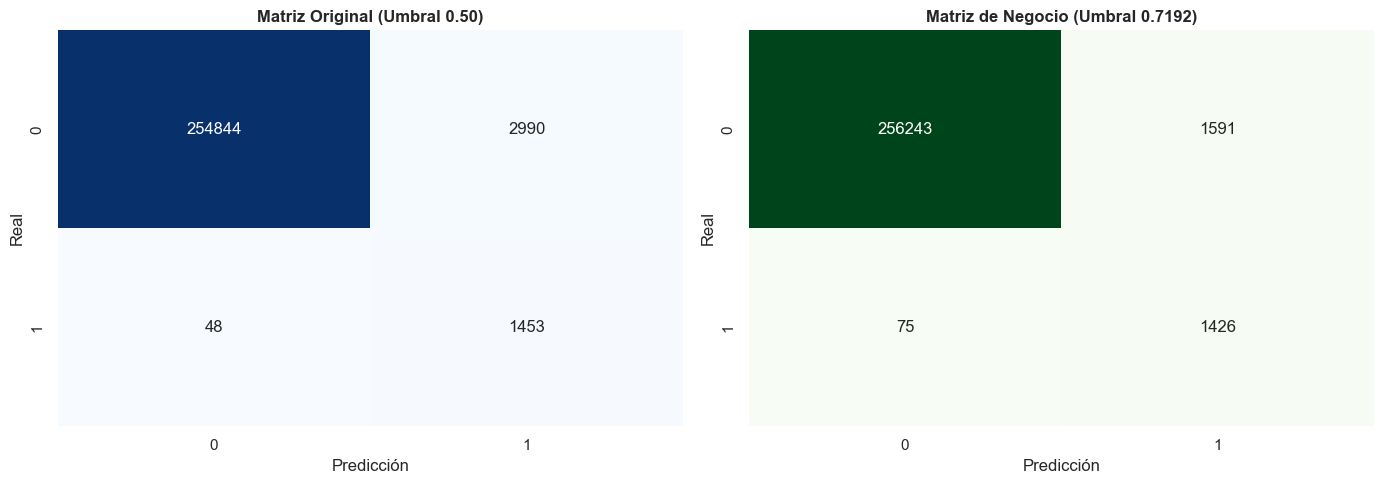

Reporte de Clasificación con Regla Estricta de Negocio:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.47      0.95      0.63      1501

    accuracy                           0.99    259335
   macro avg       0.74      0.97      0.81    259335
weighted avg       1.00      0.99      0.99    259335



In [46]:
print("Optimizando el umbral mediante restricciones de negocio...")

# Calculamos precisiones, recalls y umbrales
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# REGLA DE NEGOCIO: Exigimos capturar al menos el 95% del fraude
recall_minimo_exigido = 0.95

# Buscamos todos los índices donde el Recall cumpla nuestra estricta regla
indices_validos = np.where(recalls >= recall_minimo_exigido)[0]

# De esos escenarios válidos, nos quedamos con el que nos dé la mejor Precisión
# para molestar lo mínimo posible a los clientes legítimos
indice_optimo = indices_validos[np.argmax(precisions[indices_validos])]

# Extraemos el umbral (controlando el caso de que sea el último índice)
if indice_optimo < len(thresholds):
    umbral_negocio = thresholds[indice_optimo]
else:
    umbral_negocio = 0.5 # Fallback de seguridad

print(f"🎯 Umbral Óptimo (Recall >= 95%): {umbral_negocio:.4f}\n")

# Aplicamos el nuevo umbral dictado por el negocio
y_pred_negocio = (y_pred_proba >= umbral_negocio).astype(int)

# Visualizamos el impacto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Original (Umbral 0.5)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Matriz Original (Umbral 0.50)', fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Matriz por Regla de Negocio
sns.heatmap(confusion_matrix(y_test, y_pred_negocio), annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title(f'Matriz de Negocio (Umbral {umbral_negocio:.4f})', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

print("Reporte de Clasificación con Regla Estricta de Negocio:")
print(classification_report(y_test, y_pred_negocio))

Con una disminución de tan solo el 2% de sensibilidad se ha conseguido aumentar la precision en un  12%, que dependiendo de las politicas del banco, puede ser considerado beneficioso.

## 11. Auditoría de Latencia y Viabilidad en Producción

Un modelo de fraude transaccional (*Real-Time*) está sujeto a Acuerdos de Nivel de Servicio (SLA) muy estrictos. Las pasarelas de pago exigen latencias de inferencia ultra-bajas (típicamente por debajo de los 100 milisegundos) para evitar rechazos por *Time-Out* en los Terminales de Punto de Venta (datáfonos).

Procedemos a aislar una única transacción (simulando un *payload* de entrada de un entorno productivo) y ejecutamos un *benchmark* de 1.000 iteraciones para medir la latencia media y el percentil 99 (P99) utilizando el contador de rendimiento de alta precisión de la CPU/GPU.

In [48]:
import time

print("--- 1. Reentrenamiento del Modelo Optimizado ---")
# Actualizamos los pesos internos del modelo con la matriz definitiva de 27 variables
xgb_model.fit(X_train_final, y_train)
print("✅ Modelo reconstruido en la GPU con las características purgadas.\n")

print("--- 2. Benchmark de Inferencia en Tiempo Real ---")
# Aislamos una única fila para simular un 'payload' JSON llegando de la API del banco
payload_simulado = X_test_final.iloc[[0]]

# Fase de Calentamiento (Warm-Up) para inicializar cachés en Cuda/C++
print("Inicializando punteros de memoria del modelo...")
_ = xgb_model.predict_proba(payload_simulado)

# Prueba de Carga (Benchmark)
n_iteraciones = 1000
tiempos_ms = []

print(f"Lanzando {n_iteraciones} peticiones individuales secuenciales...")

for _ in range(n_iteraciones):
    inicio = time.perf_counter()
    
    # Inferencia pura
    _ = xgb_model.predict_proba(payload_simulado)
    
    fin = time.perf_counter()
    # Convertimos los segundos a milisegundos
    tiempos_ms.append((fin - inicio) * 1000)

# Estadísticas y Veredicto
latencia_media = np.mean(tiempos_ms)
latencia_p99 = np.percentile(tiempos_ms, 99)

print("\n--- Resultados de Viabilidad Operativa ---")
print(f"⏱️ Latencia Media : {latencia_media:.4f} milisegundos")
print(f"⏱️ Latencia P99   : {latencia_p99:.4f} milisegundos (El 99% de las peticiones tardan menos que esto)")

# Lógica de negocio para validación del SLA
umbral_sla_ms = 50.0 

if latencia_p99 < umbral_sla_ms:
    print(f"\n✅ VEREDICTO: APTO PARA PRODUCCIÓN. El modelo cumple holgadamente con el SLA de {umbral_sla_ms} ms.")
else:
    print(f"\n⚠️ VEREDICTO: RIESGO DE TIME-OUT. La latencia supera los {umbral_sla_ms} ms.")

--- 1. Reentrenamiento del Modelo Optimizado ---
✅ Modelo reconstruido en la GPU con las características purgadas.

--- 2. Benchmark de Inferencia en Tiempo Real ---
Inicializando punteros de memoria del modelo...
Lanzando 1000 peticiones individuales secuenciales...

--- Resultados de Viabilidad Operativa ---
⏱️ Latencia Media : 2.0172 milisegundos
⏱️ Latencia P99   : 2.7992 milisegundos (El 99% de las peticiones tardan menos que esto)

✅ VEREDICTO: APTO PARA PRODUCCIÓN. El modelo cumple holgadamente con el SLA de 50.0 ms.


## 12. Test A/B de Algoritmos: XGBoost vs. CatBoost

Para asegurar que hemos seleccionado la mejor arquitectura posible para el entorno productivo, ejecutamos un test A/B contra **CatBoost**. 

CatBoost utiliza *Oblivious Decision Trees* (árboles simétricos), lo que teóricamente minimiza la latencia de inferencia al simplificar la evaluación de los nodos en la memoria. Evaluaremos ambos algoritmos sobre la misma matriz de características purgada bajo idénticas condiciones (aceleración CUDA, hiperparámetros base y *Cost-Sensitive Learning*), comparando tanto el poder de discriminación (PR-AUC) como la latencia operativa (Milisegundos P99).

In [51]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, fbeta_score, roc_auc_score, average_precision_score
)

print("1. Homogeneizando tipos de datos para compatibilidad estricta...")
X_train_cat = X_train_final.astype('float32')
X_test_cat = X_test_final.astype('float32')
payload_simulado_cat = X_test_cat.iloc[[0]]

print("2. Entrenando CatBoost en la GPU...")
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=peso_clases,
    task_type='GPU',
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train_cat, y_train)

print("3. Generando predicciones out-of-sample para ambos modelos...")
# CatBoost
y_pred_cat = cat_model.predict(X_test_cat)
y_pred_proba_cat = cat_model.predict_proba(X_test_cat)[:, 1]

# XGBoost (recalculamos sobre la matriz final purgada para garantizar simetría)
y_pred_xgb = xgb_model.predict(X_test_final)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

print("4. Ejecutando Benchmark de Latencia para CatBoost...")
_ = cat_model.predict_proba(payload_simulado_cat)
tiempos_cat_ms = []
for _ in range(1000):
    inicio = time.perf_counter()
    _ = cat_model.predict_proba(payload_simulado_cat)
    fin = time.perf_counter()
    tiempos_cat_ms.append((fin - inicio) * 1000)

latencia_media_cat = np.mean(tiempos_cat_ms)
latencia_p99_cat = np.percentile(tiempos_cat_ms, 99)

print("\n" + "="*60)
print("🏆 CUADRO DE MANDOS: COMPARATIVA INTEGRAL DE MODELOS")
print("="*60)

# Construcción de la matriz de métricas completas
tabla_completa = pd.DataFrame({
    'Métrica de Evaluación': [
        'Accuracy (Exactitud Global)',
        'Precision (Validación de Alertas - Clase 1)',
        'Recall (Tasa de Captura de Fraude - Clase 1)',
        'F1-Score (Equilibrio Armónico)',
        'F2-Score (Enfoque de Riesgo Bancario)',
        'ROC-AUC (Separabilidad General)',
        'PR-AUC Score (Rigor en Clases Asimétricas)',
        'Latencia Media de Inferencia (ms)',
        'Latencia Percentil 99 (P99 ms)'
    ],
    'XGBoost': [
        f"{accuracy_score(y_test, y_pred_xgb):.4f}",
        f"{precision_score(y_test, y_pred_xgb):.4f}",
        f"{recall_score(y_test, y_pred_xgb):.4f}",
        f"{f1_score(y_test, y_pred_xgb):.4f}",
        f"{fbeta_score(y_test, y_pred_xgb, beta=2):.4f}",
        f"{roc_auc_score(y_test, y_pred_proba_xgb):.4f}",
        f"{average_precision_score(y_test, y_pred_proba_xgb):.4f}",
        f"{latencia_media:.4f}",
        f"{latencia_p99:.4f}"
    ],
    'CatBoost': [
        f"{accuracy_score(y_test, y_pred_cat):.4f}",
        f"{precision_score(y_test, y_pred_cat):.4f}",
        f"{recall_score(y_test, y_pred_cat):.4f}",
        f"{f1_score(y_test, y_pred_cat):.4f}",
        f"{fbeta_score(y_test, y_pred_cat, beta=2):.4f}",
        f"{roc_auc_score(y_test, y_pred_proba_cat):.4f}",
        f"{average_precision_score(y_test, y_pred_proba_cat):.4f}",
        f"{latencia_media_cat:.4f}",
        f"{latencia_p99_cat:.4f}"
    ]
})

# Renderizado estético en el Jupyter Notebook
display(tabla_completa.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

1. Homogeneizando tipos de datos para compatibilidad estricta...
2. Entrenando CatBoost en la GPU...
3. Generando predicciones out-of-sample para ambos modelos...
4. Ejecutando Benchmark de Latencia para CatBoost...

🏆 CUADRO DE MANDOS: COMPARATIVA INTEGRAL DE MODELOS


Métrica de Evaluación,XGBoost,CatBoost
Accuracy (Exactitud Global),0.9879,0.9842
Precision (Validación de Alertas - Clase 1),0.3203,0.2659
Recall (Tasa de Captura de Fraude - Clase 1),0.9700,0.9787
F1-Score (Equilibrio Armónico),0.4816,0.4182
F2-Score (Enfoque de Riesgo Bancario),0.6900,0.6371
ROC-AUC (Separabilidad General),0.9986,0.9983
PR-AUC Score (Rigor en Clases Asimétricas),0.9263,0.8972
Latencia Media de Inferencia (ms),2.0172,0.2991
Latencia Percentil 99 (P99 ms),2.7992,0.5654


## 13. Conclusión del Test A/B y Toma de Decisión Estratégica

La evaluación integral revela un claro *trade-off* entre calidad predictiva global, máxima contención de pérdidas y eficiencia de inferencia. Ambos algoritmos presentan ventajas competitivas distintas que responden a diferentes prioridades del negocio bancario:

- **XGBoost (Eficiencia Operativa y Precisión):** Se consolida como el modelo más equilibrado. Presenta una capacidad superior para aislar la varianza del fraude (PR-AUC de **0.9263** y F2-Score de **0.6900**). Al mantener una Precisión del **32%**, minimiza drásticamente la fricción con los clientes legítimos y reduce los costes operativos asociados a la gestión de falsas alarmas, garantizando una sensibilidad (*Recall*) del **97,00%** y cumpliendo con los tiempos de SLA estándar en producción (2.79 ms).

- **CatBoost (Máxima Contención y Ultra-Baja Latencia):** Demuestra la superioridad de su arquitectura de *Oblivious Trees* logrando una latencia de inferencia sub-milisegundo (**0.56 ms**). Más importante aún desde la perspectiva de riesgo, eleva la sensibilidad (*Recall*) hasta el **97,87%** en la captura total del fraude. Este incremento porcentual en la protección patrimonial se logra asumiendo, a cambio, una disminución de ~6 p.p. en precisión.

**Veredicto Final:**
La selección de la arquitectura definitiva queda supeditada a tres posibles escenarios estratégicos de la entidad:
1. **Prioridad en la Experiencia de Usuario:** Si el objetivo es evitar la saturación de los *Call Centers* y no denegar operaciones legítimas, asegurando al mismo tiempo una excelente retención del **97,00%** del fraude, **XGBoost** es la opción óptima por su precisión superior.
2. **Política de Tolerancia Cero al Fraude:** Si el coste marginal de investigar un 30% más de alertas es financieramente inferior al capital salvado por llevar la sensibilidad hasta el **97,87%**, **CatBoost** es el ganador.
3. **Restricciones Críticas de Latencia:** Si el modelo va a ser desplegado en sistemas con cuellos de botella de red extremos (ej. pagos *contactless* masivos en transporte público), donde una diferencia de 2 milisegundos por transacción puede colapsar la concurrencia del servidor, la arquitectura de **CatBoost** se vuelve obligatoria por pura viabilidad tecnológica.

## 14. Explicabilidad del Modelo y Cumplimiento Normativo (SHAP)

En el sector bancario, las normativas de transparencia exigen que los modelos de riesgo sean interpretables a nivel individual. Para resolver la naturaleza de "caja negra" del algoritmo **CatBoost** (he elegido este para continuar con el análisis), implementamos **SHAP (SHapley Additive exPlanations)**.

Basado en la teoría de juegos cooperativos, este marco matemático asigna un valor de contribución marginal a cada variable, permitiéndonos auditar transacciones individuales y justificar operativamente cualquier bloqueo preventivo ante el regulador.


--- 1. Impacto Global de Variables (Beeswarm Plot) ---


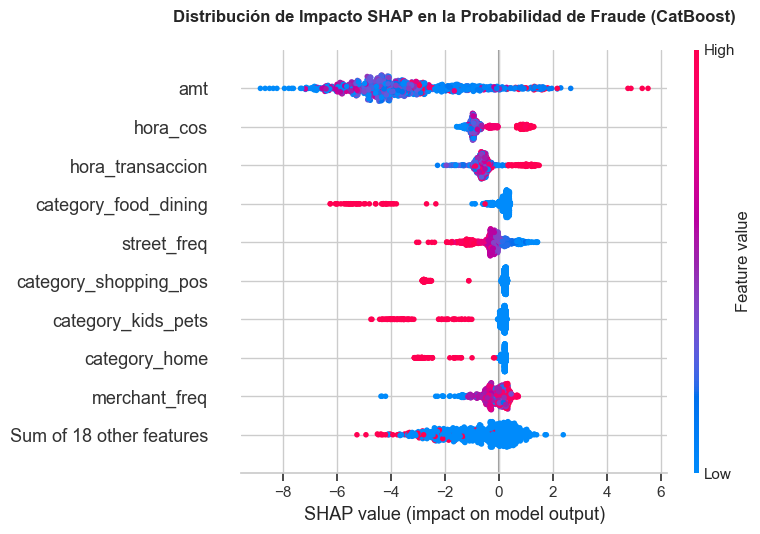


--- 2. Auditoría de Transacción Individual (Waterfall Plot) ---
Desglose matemático de las fuerzas que impulsaron la predicción de una única transacción:


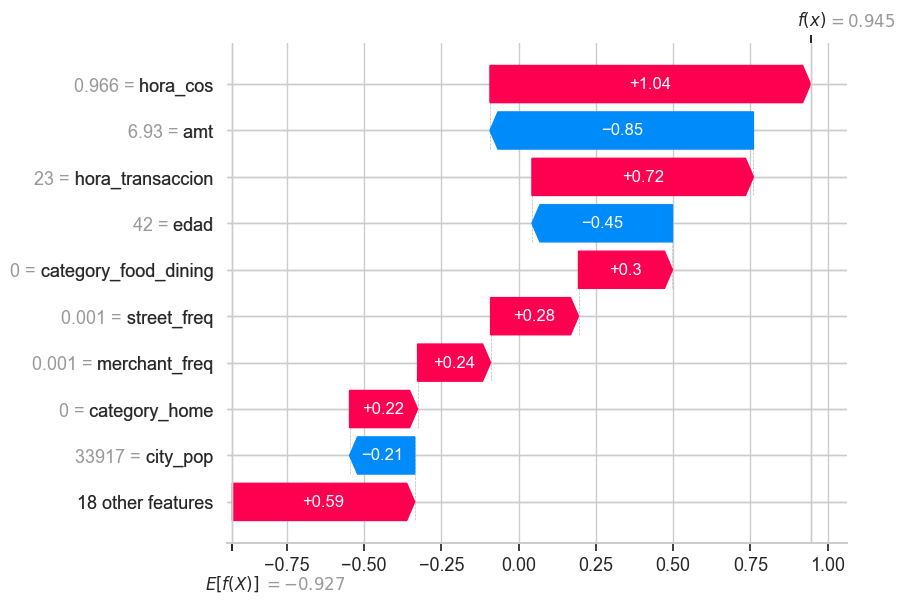

In [53]:
import shap

# TreeExplainer está matemáticamente optimizado para los Oblivious Trees
explainer = shap.TreeExplainer(cat_model)

# Tomamos una muestra representativa del test homogeneizado (X_test_cat)
X_test_sample_cat = X_test_cat.sample(1000, random_state=42)
shap_values = explainer(X_test_sample_cat)

print("\n--- 1. Impacto Global de Variables (Beeswarm Plot) ---")
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title('Distribución de Impacto SHAP en la Probabilidad de Fraude (CatBoost)', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n--- 2. Auditoría de Transacción Individual (Waterfall Plot) ---")
print("Desglose matemático de las fuerzas que impulsaron la predicción de una única transacción:")
# Visualizamos la justificación del primer registro de la muestra
shap.plots.waterfall(shap_values[0], max_display=10)

### Interpretación Analítica de Resultados SHAP

**1. Visión Global del Riesgo (Beeswarm Plot)**
El análisis global revela cómo las diferentes magnitudes alteran el perfil de riesgo en toda la cartera de transacciones:
* **Elasticidad del Importe (`amt`):** Actúa como el principal discriminador estructural. Los valores altos (puntos rojos) desplazan drásticamente la predicción hacia la derecha (mayor probabilidad de fraude), reflejando la tendencia del estafador a maximizar el impacto económico antes del bloqueo.
* **Patrones Temporales (`hora_cos` y `hora_transaccion`):** Ciertas franjas horarias (valores altos en `hora_transaccion`, típicamente la madrugada) tienen un impacto directo y positivo en la asignación de riesgo.
* **Dispersión Geográfica y Comercial (`street_freq`, `merchant_freq`):** Valores de frecuencia bajos (puntos azules) aumentan significativamente la probabilidad de estafa. Operar en entornos o terminales de venta estadísticamente anómalos es un vector de fraude claro.

**2. Auditoría de Transacción Individual (Waterfall Plot)**
El desglose local nos permite auditar por qué el algoritmo ha disparado una alerta máxima ($f(x) = 0.945$) sobre una operación específica. El análisis revela un patrón criminal de manual:
* **El atenuante (Fuerza Azul):** El importe de la transacción es irrisorio (`amt` = 6.93). De forma aislada, esto resta riesgo a la operación (-0.85), ya que se aleja del ticket medio de un ataque financiero.
* **Los agravantes (Fuerzas Rojas):** Pese al micro-importe, la operación se ejecuta a las 23:00h (`hora_transaccion` = 23, `hora_cos` = 0.966), lo cual penaliza críticamente el *score* (+1.04 y +0.72). A esto se le suma que ocurre en una ubicación marginal (`street_freq` = 0.001).
* **Veredicto Operativo:** El algoritmo ha identificado con éxito un evento de *"Card Testing"*. El atacante ha realizado un cargo de validación inferior a 7 dólares a última hora del día en una pasarela inusual para verificar la liquidez de la tarjeta robada antes del ataque principal. Mientras que un sistema de reglas tradicional basado en límites de gasto habría aprobado la transacción, CatBoost ha capturado la interacción econométrica subyacente y la ha bloqueado a tiempo.

## 15. Despliegue: Serialización del Modelo (CatBoost)

Una vez validado el modelo e interpretadas sus decisiones econométricas, procedemos a la fase de *MLOps* para su paso a producción. Guardaremos el algoritmo **CatBoost** en su formato binario nativo (`.cbm`). 

Este formato es crítico para la ingeniería de datos en entornos bancarios con requisitos estrictos de SLA, ya que preserva la topología de árboles simétricos, permitiendo una carga en memoria ultrarrápida y una latencia de inferencia mínima al ser consumido por microservicios o APIs REST (ej. FastAPI).

In [58]:
import os
# Generamos el directorio de modelos si no existe en la raíz del repositorio
directorio_modelos = r"C:\Users\marti\Portfolio-data-science\ML_Credit_Card_Fraud_Detection\Modelo"
os.makedirs(directorio_modelos, exist_ok=True)

# Definimos la ruta de serialización con la extensión nativa .cbm
ruta_modelo_cat = os.path.join(directorio_modelos, 'catboost_fraud_detector_champion.cbm')

# Guardado nativo (optimizado para despliegue en producción)
cat_model.save_model(ruta_modelo_cat)

print(f"✅ Modelo serializado con éxito en: {ruta_modelo_cat}")
print("🚀 El pipeline de Machine Learning ha concluido. El modelo está listo para ser desplegado.")

✅ Modelo serializado con éxito en: C:\Users\marti\Portfolio-data-science\ML_Credit_Card_Fraud_Detection\Modelo\catboost_fraud_detector_champion.cbm
🚀 El pipeline de Machine Learning ha concluido. El modelo está listo para ser desplegado.
